# [1.3.1] Linear probes ⑦ — 반박 2: 읽힘과 쓰임

1부의 논증에는 세 개의 다리가 있었다. **읽힌다**(①②), **밀면 바뀐다**(④), 그리고 그 둘을 잇는 암묵적 가정 — "읽히는 방향이 곧 모델이 쓰는 변수다." 심사위원은 이 다리를 하나씩 두드린다.

| 심사위원의 질문 | 겨누는 주장 | 이 notebook의 실험 |
|---|---|---|
| "아무 개념이나 probe로 읽히지 않나?" | C2 (선택성) | 1️⃣ 만들어 낸 개념 |
| "그 정보를 **지우면** 판단을 못 하나?" | C4 (필요성) | 2️⃣ LEACE로 지우기 |
| "probe가 찾은 방향이 모델이 쓰는 특징인가?" | C4 (해석) | 3️⃣ 착시 논쟁과 위치 이동 |
| "선형이 아닌 표현이라면?" | 방법론 전체 | 4️⃣ 요일의 원형 표현 |

미리 말해 두면, 이 notebook에서는 1부의 주장 하나가 **오히려 강해진다.** 반박은 무너뜨리는 일이 아니라 경계를 재는 일이다.

## 학습 목표, 필수 경로, stop rule

1. 선형 probe가 모델에 없는 "개념"도 높은 AUROC로 읽어 낸다는 것을 보이고, 그때 진실 probe를 구별해 주는 증거가 무엇이었는지 말한다.
2. amnesic probing(지우고 행동 보기)을 LEACE로 구현하고, **지우는 분포와 위치**가 결론을 어떻게 뒤집는지 본다.
3. "가장 잘 읽히는 곳"과 "판단에 쓰이는 곳"이 다를 수 있다는 것을 ④와 이 notebook의 결과로 설명한다.
4. 선형 probe의 성공·실패가 표현의 **기하**에 대해 무엇을 말하지 않는지 예로 든다.

### ⑧로 넘어가도 되는 기준

- "probe 방향을 지웠는데 행동이 그대로다 → 모델은 그 정보를 안 쓴다"는 추론이 왜 성급한지, 이 notebook의 실제 숫자로 설명할 수 있다.
- 충분성(④)과 필요성(2️⃣)이 각각 무엇을 보이는지 구분할 수 있다.

## 공통 setup

#### Cell 01 · 실행 환경과 공통 import

- **이번 셀의 질문:** 환경이 같은가?
- **출력에서 볼 것:** 버전과 GPU를 확인한다.
- **해석 범위:** 환경 확인만 한다.
- **다음 단계의 목적:** 모델과 1부의 split·probe를 재현한다.

In [1]:
# 공통 setup — import는 이 셀 한 곳에서만 한다.
from __future__ import annotations

import gc
import sys
from importlib.metadata import version
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():  # 저장소 root 등 다른 위치에서 연 경우
    HERE = next(
        p
        for p in [HERE / "chapter1_transformer_interp/exercises/part31_linear_probes_ko", *HERE.parents]
        if (p / "probe_lab.py").exists()
    )
sys.path.insert(0, str(HERE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import probe_lab as pl
import tests

pl.use_style()
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print({
    "torch": torch.__version__,
    "transformers": version("transformers"),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "model": pl.DEFAULT_MODEL,
})

{'torch': '2.11.0+cu128', 'transformers': '5.18.0', 'gpu': 'NVIDIA RTX A6000', 'model': 'meta-llama/Llama-3.1-8B-Instruct'}


#### Cell 02 · 모델, split, layer 12 activation

- **이번 셀의 질문:** 1부와 같은 설정인가?
- **출력에서 볼 것:** split 크기와 PROBE_LAYER=12를 확인한다.
- **해석 범위:** few-shot prompt 안의 activation은 2️⃣에서 따로 뽑는다.
- **다음 단계의 목적:** 첫 번째 질문: 만들어 낸 개념.

In [2]:
model, tok = pl.load_model(pl.DEFAULT_MODEL)
store = pl.ActivationStore(model=model, tokenizer=tok)
N_LAYERS = len(pl.decoder_layers(model))
print({"layers": N_LAYERS, "d_model": model.config.hidden_size,
       "dtype": str(next(model.parameters()).dtype),
       "GPU GiB": round(torch.cuda.memory_allocated() / 2**30, 1) if torch.cuda.is_available() else None})

cities = pl.load_dataset("cities")
y = cities["label"].to_numpy()
split = pl.group_split(cities["group"].to_numpy(), seed=0)
tr, va, te = split.train, split.val, split.test
PROBE_LAYER = pl.load_results("01_observation")["probe_layer"]
X = store.dataset("cities", [PROBE_LAYER])[PROBE_LAYER]
print({"split": (len(tr), len(va), len(te)), "PROBE_LAYER": PROBE_LAYER})

{'layers': 32, 'd_model': 4096, 'dtype': 'torch.bfloat16', 'GPU GiB': 15.0}
{'split': (898, 300, 298), 'PROBE_LAYER': 12}


# 1️⃣ 만들어 낸 개념도 읽힌다

108개 국가를 **무작위로** 두 묶음 A/B로 나누고, 각 문장에 "국가가 A 묶음인가"라는 label을 붙인다. 이런 개념은 모델이 학습했을 리 없다. 그래도 선형 probe로 읽힐까?

비교 대상 두 개를 함께 본다.
- **실재하지만 무관한 개념:** "국가가 아시아에 있는가"
- **처음 보는 entity의 무작위 label:** 도시마다 무작위 label (test 도시는 train에 없다)

이것은 [Hewitt & Liang (2019)](https://arxiv.org/abs/1909.03368)의 *control task*와 같은 생각이다. probe의 정확도에서 control task의 정확도를 뺀 것이 *selectivity*다.

#### Cell 03 · 만들어 낸 개념, 무관한 개념, 무작위 도시 label

- **이번 셀의 질문:** 모델에 없을 것이 분명한 개념도 layer 12에서 선형으로 읽히는가?
- **출력에서 볼 것:** 저장된 출력: 무작위 국가 묶음 LR test AUROC **0.99**, MM 0.73. 아시아 여부 LR 0.997, MM 0.85. 처음 보는 도시의 무작위 label은 0.45(우연).
- **해석 범위:** 모델은 '국가가 무엇인가'를 선형으로 표현한다. 그러면 국가에 대한 **어떤 함수든**(무작위 묶음이라도) LR이 조합해 낸다. 높은 AUROC는 'label이 표현된 특징들의 선형 함수로 쓸 수 있다'는 뜻이지 '모델이 그 개념을 가진다'는 뜻이 아니다. MM이 0.73에 그치는 것은 MM이 평균 차이 방향 하나만 쓰기 때문이다(조합 능력이 약하다).
- **다음 단계의 목적:** 그렇다면 1부에서 진실 probe를 '만들어 낸 개념'과 구별해 준 증거는 무엇이었는지 정리한다.

In [3]:
rng = np.random.default_rng(0)
countries = cities["country"].unique()
partition = {c: int(rng.random() < 0.5) for c in countries}
city_label = {c: int(rng.random() < 0.5) for c in cities["city"].unique()}
ASIA = {"China", "India", "Japan", "South Korea", "Indonesia", "Pakistan", "Bangladesh", "Vietnam", "the Philippines",
        "Thailand", "Iran", "Iraq", "Saudi Arabia", "Turkey", "Malaysia", "Myanmar", "Afghanistan", "Uzbekistan",
        "Kazakhstan", "Nepal", "Sri Lanka", "Syria", "Yemen", "Israel", "Jordan", "the United Arab Emirates", "Cambodia",
        "Taiwan", "North Korea", "Mongolia", "Kyrgyzstan", "Tajikistan", "Turkmenistan", "Laos", "Lebanon", "Kuwait",
        "Qatar", "Oman", "Azerbaijan", "Armenia", "Georgia", "Singapore", "Bahrain"}
concepts = {
    "truth (real label)": y,
    "random country partition (made-up)": cities["country"].map(partition).to_numpy(),
    "country in Asia (real, irrelevant)": cities["country"].isin(ASIA).astype(int).to_numpy(),
    "random label per city (unseen at test)": cities["city"].map(city_label).to_numpy(),
}
rows = []
for name, lab in concepts.items():
    lr_c = pl.fit_logistic(X[tr], lab[tr], C=0.1)
    mm_c = pl.fit_mass_mean(X[tr], lab[tr])
    rows.append({"label": name, "positive rate": lab.mean(),
                 "LR test AUROC": pl.auroc(lab[te], lr_c.score(X[te])), "MM test AUROC": pl.auroc(lab[te], mm_c.score(X[te]))})
made_up = pd.DataFrame(rows).set_index("label")
display(made_up)

,positive rate,LR test AUROC,MM test AUROC
label,,,
truth (real label),0.500,1.000,1.000
random country partition (made-up),0.354,0.987,0.732
"country in Asia (real, irrelevant)",0.614,0.997,0.851
random label per city (unseen at test),0.488,0.448,0.488


### 해석 checkpoint — 그럼 1부의 증거 중 무엇이 진실 probe를 구별했나

- **읽힘(①)과 귀무분포(②)는 구별하지 못한다.** 무작위 국가 묶음도 test AUROC 0.99로 읽히고, label을 섞은 귀무분포보다 훨씬 높다. C2("probe 용량으로 설명되지 않는다")는 맞지만, 그것이 "모델이 이 개념을 가진다"를 뜻하지는 않는다.
- **일반화(③)는 구별한다.** 무작위 국가 묶음 방향을 스페인어 단어 문장에 적용하는 것은 의미조차 없다. cities 진실 방향은 cities와 무관한 데이터로 옮겨 갔다. 다만 ⑥에서 보았듯 그 "공통 변수"는 극성 의존 성분을 섞고 있었다.
- **개입(④)도 구별한다.** 무작위 국가 묶음 방향으로 밀어서 TRUE/FALSE 판단이 바뀔 이유는 없다(직접 해 보는 것은 선택 과제).

일반 원칙: **정확도는 "읽을 수 있다"까지만 증명한다.** 개념에 대한 주장은 정확도 바깥의 증거(일반화, 개입, 대조 과제)에서 온다.

# 2️⃣ 지워 보기 — 필요성 시험

④는 **충분성**을 보였다: 그 방향으로 밀면 판단이 바뀐다. 반대 질문은 **필요성**이다: 그 정보를 없애면 판단을 못 하는가? 이 질문을 실험으로 만든 것이 *amnesic probing*이다([Elazar et al. 2021](https://arxiv.org/abs/2006.00995)). 정보를 지우고 행동이 변하는지 본다.

먼저 "지운다"를 정확히 정의해야 한다. 이진 label에 대해 다음 둘은 같은 말이다([Belrose et al. 2023](https://arxiv.org/abs/2306.03819)).

- 어떤 선형 분류기도 상수 예측보다 나을 수 없다 (*linear guardedness*)
- **두 class의 평균이 같다** ($\mu_1 = \mu_0$)

이유는 간단하다. 선형으로 분리된다면 $w^\top x + b$가 class 1에서 양수, class 0에서 음수이므로 평균을 내면 $w^\top(\mu_1 - \mu_0) > 0$이어야 한다. 그리고 logistic loss의 $w = 0$에서의 기울기는 $\mu_1 - \mu_0$에 비례하므로, 두 평균이 같으면 $w = 0$이 (볼록 함수의) 최적해다.

그러면 지우는 방법에 따라 결과가 갈린다.
- **LR probe 방향을 직교 사영으로 지우기** (INLP의 한 단계, [Ravfogel et al. 2020](https://arxiv.org/abs/2004.07667)): LR 방향은 평균 차이 방향과 다르므로(①: cos 0.49) 두 평균은 여전히 다르다. 정보가 남는다.
- **평균 차이 방향(MM)을 직교 사영으로 지우기:** 두 평균이 같아진다. 선형 정보가 사라진다.
- **LEACE:** 두 평균을 같게 만드는 변환 중 **activation을 가장 적게 바꾸는** 닫힌 형태의 해다. $x' = x - W^{+} P\, W (x - \mu)$ ($W = \Sigma^{-1/2}$, $P$ = 백색화 공간에서 교차공분산 방향으로의 사영).

### ✏️ Exercise 9 · 세 가지 지우기

> 난이도 🔴🔴🔴⚪⚪ · 중요도 🔵🔵🔵🔵⚪ · 20~30분

1. `project_out(X, u)`: 방향 $u$를 직교 사영으로 지운다 ($x - (x\cdot\hat u)\hat u$).
2. `my_leace(X, y)`: 위 식대로 eraser 함수를 만든다. $\Sigma$의 고유분해에서 아주 작은 고유값은 버린다($n < d$라 $\Sigma$는 계수가 부족하다).

아래 reference 셀은 세 방법으로 layer 12 activation을 지운 뒤 **새 LR probe를 다시 학습**해 test AUROC를 잰다. LR 방향을 지운 결과를 `tests.test_eraser`에 넣으면 실패하는 것이 정상이다.

In [4]:
# Scratch
MY_IMPL = False

def project_out(X: np.ndarray, u: np.ndarray) -> np.ndarray:
    raise NotImplementedError

def my_leace(X: np.ndarray, y: np.ndarray):
    """Returns: erase(X) 함수."""
    raise NotImplementedError

if MY_IMPL:
    tests.test_eraser(my_leace)

#### Cell 04 · 세 가지 지우기와 다시 학습한 probe

- **이번 셀의 질문:** LR 방향, 평균 차이 방향, LEACE — 무엇을 지워야 진실 정보가 선형으로 사라지는가?
- **출력에서 볼 것:** 저장된 출력: **LR 방향을 지우면 다시 학습한 LR이 test AUROC 1.000**으로 그대로 읽는다(같은 단계를 8번 반복해도 1.000). 평균 차이 방향을 지우면 0.500, LEACE는 0.55. 두 class 평균의 거리는 LR 방향 제거 후 3.9, 나머지 둘은 0이다. 평균 변화량은 평균 차이 사영과 LEACE가 거의 같다(약 2.23).
- **해석 범위:** 'probe 방향을 지웠다'는 말은 **어느 probe**인지에 따라 정반대의 결과를 낸다. 분류를 잘하는 방향(LR)과 정보가 실린 방향(평균 차이)은 다르다. ①의 toy, ④의 개입과 같은 교훈이다. LEACE의 보장은 **eraser를 맞춘 분포(train 문장, 이 층, 이 위치)** 에서의 선형 정보 제거다. 다른 분포·다른 위치·비선형 정보에는 보장이 없다. 다음 실험에서 이 단서가 결정적이 된다.
- **다음 단계의 목적:** 지운 activation으로 모델의 행동을 시험한다.

In [5]:
tests.test_eraser(pl.fit_leace)


def project_out_reference(X: np.ndarray, u: np.ndarray) -> np.ndarray:
    u = u / np.linalg.norm(u)
    return X - np.outer(X @ u, u)


w_lr = pl.fit_logistic(X[tr], y[tr], C=0.1).direction
u_mm = pl.fit_mass_mean(X[tr], y[tr]).unit
X_inlp = X.copy()
for _ in range(8):                                    # INLP: LR 방향을 8번 연속으로 지운다
    X_inlp = project_out_reference(X_inlp, pl.fit_logistic(X_inlp[tr], y[tr], C=0.1).direction)
erased = {
    "original": X,
    "LR direction projected out (1 step)": project_out_reference(X, w_lr),
    "LR directions projected out (8 INLP steps)": X_inlp,
    "mean-difference direction projected out": project_out_reference(X, u_mm),
    "LEACE": pl.fit_leace(X[tr], y[tr])(X),
}
rows = []
for name, Xe in erased.items():
    rows.append({"erasure": name,
                 "retrained LR test AUROC": pl.auroc(y[te], pl.fit_logistic(Xe[tr], y[tr], C=0.1).score(Xe[te])),
                 "||mu1 - mu0|| (train)": np.linalg.norm(Xe[tr][y[tr] == 1].mean(0) - Xe[tr][y[tr] == 0].mean(0)),
                 "mean ||x' - x||": np.linalg.norm(Xe - X, axis=1).mean()})
erasure = pd.DataFrame(rows).set_index("erasure")
display(erasure.round(3))

✅ eraser: 지운 뒤 재학습 LR AUROC 0.498, 평균 변화량 0.73 (중심화된 norm 대비)


,retrained LR test AUROC,||mu1 - mu0|| (train),mean ||x' - x||
erasure,,,
original,1.00,4.486,0.000
LR direction projected out (1 step),1.00,3.909,1.096
LR directions projected out (8 INLP steps),1.00,3.138,1.654
mean-difference direction projected out,0.50,0.000,2.233
LEACE,0.55,0.002,2.231


## 세 번의 지우기 실험

모델의 forward 도중 few-shot prompt의 특정 위치·층에서 activation을 LEACE로 지우고, $P(\text{TRUE}) - P(\text{FALSE})$로 판단이 유지되는지 본다(test 도시 298문장).

| 실험 | eraser를 맞춘 데이터 | 지우는 위치 | 지우는 층 |
|---|---|---|---|
| **A** | 1부의 probe와 같은 **문장 단독** activation | 문장 끝 두 위치(마지막 단어, 마침표) | 8–12 |
| **B** | **few-shot prompt 안**에서의 activation | 같은 두 위치 | 8–12 |
| **C** | few-shot prompt 안에서의 activation | 끝의 여섯 위치(마지막 단어, 마침표, ` This`, ` statement`, ` is`, `:`) | 12–20 |

각 실험에는 **label을 섞어 맞춘 eraser**(같은 크기의 무작위 rank-1 제거)를 대조군으로 붙인다. 진짜 eraser가 판단을 망가뜨리고 섞은 eraser는 그렇지 않아야 "진실 정보를 지운 효과"라고 말할 수 있다.

#### Cell 05 · few-shot prompt 안의 activation 모으기

- **이번 셀의 질문:** few-shot prompt 안에서 같은 문장의 activation은 문장 단독일 때와 같은가?
- **출력에서 볼 것:** train 898문장에 대해 layer 8–20, 끝의 여섯 위치의 activation을 모은다. 문장 단독 MM 방향과 prompt 안 MM 방향의 cosine을 본다(저장된 출력: 마침표 위치, layer 12에서 **0.23**). prompt 안에서도 `:` 위치의 probe는 train에서 AUROC 1.0이다.
- **해석 범위:** 같은 문장이라도 앞에 few-shot 예시가 붙으면 activation의 분포가 달라진다. cosine 0.23은 '문장 단독으로 찾은 진실 방향'과 '같은 문장을 prompt 안에서 볼 때의 진실 방향'이 **상당히 다르다**는 뜻이다. 그런데도 ④의 개입이 통했던 것은, 두 방향이 완전히 직교하지는 않고 개입의 크기가 컸기 때문일 수 있다.
- **다음 단계의 목적:** 실험 A·B·C의 eraser를 맞춘다.

In [6]:
prompts = pl.build_prompts(cities["statement"].tolist())
K_ALL = [0, 1, 2, 3, 4, 5]                 # 끝에서 k번째: 0=':', 1='is', 2='statement', 3='This', 4='.', 5=마지막 단어
K_STATEMENT = list(pl.suffix_positions(tok)[::-1])   # [4, 5] = 마침표, 마지막 단어
CTX_LAYERS = list(range(8, 21))
ctx_tr = pl.context_activations(model, tok, [prompts[i] for i in tr], CTX_LAYERS, K_ALL)

stmt_dir = pl.fit_mass_mean(X[tr], y[tr]).direction
ctx_dir = pl.fit_mass_mean(ctx_tr[(PROBE_LAYER, 4)], y[tr]).direction
print("cos(statement-alone MM dir, in-context MM dir) at layer 12, period:", round(pl.cosine(stmt_dir, ctx_dir), 3))
print("in-context probe at ':' position, layer 12 — train-split AUROC:",
      round(pl.auroc(y[tr], pl.fit_mass_mean(ctx_tr[(PROBE_LAYER, 0)], y[tr]).score(ctx_tr[(PROBE_LAYER, 0)])), 3))

cos(statement-alone MM dir, in-context MM dir) at layer 12, period: 0.233
in-context probe at ':' position, layer 12 — train-split AUROC: 1.0


#### Cell 06 · eraser 맞추기 (진짜 label / 섞은 label)

- **이번 셀의 질문:** 실험 A·B·C에 필요한 eraser들을 준비한다.
- **출력에서 볼 것:** eraser 개수와 걸린 시간을 본다(GPU에서 수십 초~수 분).
- **해석 범위:** A의 eraser는 문장 단독 activation(①의 cache, 마침표와 그 앞 token)으로, B·C의 eraser는 prompt 안 activation으로 맞춘다. 섞은 label eraser는 같은 데이터에 무작위 label을 준 것이다.
- **다음 단계의 목적:** 세 실험을 실행한다.

In [7]:
import time

t0 = time.time()
stmt_acts = {4: store.dataset("cities", list(range(8, 13))),                      # 마침표 (문장 단독)
             5: store.dataset("cities", list(range(8, 13)), token_offset=-1)}     # 마지막 단어 (문장 단독)
y_shuf = np.random.default_rng(123).permutation(y[tr])


def torch_eraser(e: pl.LeaceEraser):
    mu = torch.tensor(e.mean, dtype=torch.float32, device=model.device)
    P = torch.tensor(e.proj, dtype=torch.float32, device=model.device)
    return lambda v: v - (v - mu) @ P.T


SITES = {
    "A": [(l, k) for l in range(8, 13) for k in K_STATEMENT],
    "B": [(l, k) for l in range(8, 13) for k in K_STATEMENT],
    "C": [(l, k) for l in range(12, 21) for k in K_ALL],
}
erasers = {}
for exp, sites in SITES.items():
    for labels, tag in [(y[tr], "real"), (y_shuf, "shuffled")]:
        fns = {}
        for (l, k) in sites:
            fit_X = stmt_acts[k][l][tr] if exp == "A" else ctx_tr[(l, k)]
            fns[(l, k)] = torch_eraser(pl.fit_leace(fit_X, labels))
        erasers[(exp, tag)] = fns
print({k: len(v) for k, v in erasers.items()}, f"{time.time() - t0:.0f}s")

{('A', 'real'): 10, ('A', 'shuffled'): 10, ('B', 'real'): 10, ('B', 'shuffled'): 10, ('C', 'real'): 54, ('C', 'shuffled'): 54} 45s


#### Cell 07 · 실험 A·B·C: 지운 상태의 판단

- **이번 셀의 질문:** 진실 정보를 지우면 모델은 여전히 TRUE/FALSE를 맞히는가?
- **출력에서 볼 것:** 저장된 출력: 지우기 전 판단 margin은 참 +0.99 / 거짓 −0.99다. **A(문장 단독 eraser)** 는 정확도 0.88, margin +0.65 / −0.75로 **부분적으로만** 흔든다. **B(prompt 안 eraser, 같은 위치·층)** 는 정확도 0.67, margin +0.20 / −0.20, AUROC(m) 0.70으로 판단을 크게 약화시킨다. **C(끝 여섯 위치, layer 12–20)** 는 margin을 +0.18 / +0.08로 만들어 **판단의 확신이 거의 사라지고**, 순위(AUROC(m) 0.68)도 크게 약해진다. 섞은 label eraser는 세 실험 모두 정확도 1.00, margin ±0.99로 아무 영향이 없다.
- **해석 범위:** A만 보았다면 '모델은 그 정보를 조금만 쓴다'고 **과소평가**했을 것이다. A가 약한 것은 **eraser가 다른 분포(문장 단독)에서 맞춰졌기 때문**이다(두 분포의 진실 방향 cosine 0.23). 같은 위치를 prompt 안 분포로 지우면(B) 판단이 크게 흔들리고, 정보가 옮겨 간 뒤쪽 위치까지 지우면(C) 확신이 거의 사라진다. 다만 C에서도 순위 정보(AUROC 0.68)가 일부 남는다. 우리가 지우지 않은 곳(다른 위치, 비선형 정보)에 정보가 더 있다는 뜻이다. 섞은 label 대조군이 그대로이므로 이것은 '아무거나 지워서 망가진 것'이 아니다.
- **다음 단계의 목적:** 이 결과를 ④의 충분성 결과와 합쳐 해석한다.

In [8]:
@torch.inference_mode()
def margin_with_edits(prompts_: list[str], fns: dict | None) -> np.ndarray:
    t_id, f_id = pl.answer_token_ids(tok)
    state: dict[str, torch.Tensor] = {}
    out = []
    ctx = pl.edit_residual(model, fns, lambda: state["last"]) if fns else torch.no_grad()
    with ctx:
        for s in range(0, len(prompts_), 32):
            enc = tok(prompts_[s : s + 32], return_tensors="pt", padding=True).to(model.device)
            state["last"] = enc["attention_mask"].sum(1) - 1
            logits = model(**enc).logits
            probs = logits[torch.arange(logits.shape[0], device=logits.device), state["last"]].float().softmax(-1)
            out.append((probs[:, t_id] - probs[:, f_id]).cpu())
    return torch.cat(out).numpy()


P_test, y_test = [prompts[i] for i in te], y[te]
def row(exp: str, tag: str, m: np.ndarray) -> dict:
    return {"experiment": exp, "eraser labels": tag, "accuracy": pl.accuracy(y_test, m), "AUROC(m)": pl.auroc(y_test, m),
            "mean m | true": m[y_test == 1].mean(), "mean m | false": m[y_test == 0].mean()}


rows = [row("no erasure", "—", margin_with_edits(P_test, None))]
for exp in ["A", "B", "C"]:
    for tag in ["real", "shuffled"]:
        rows.append(row(exp, tag, margin_with_edits(P_test, erasers[(exp, tag)])))
amnesic = pd.DataFrame(rows)
display(amnesic.round(3))

,experiment,eraser labels,accuracy,AUROC(m),mean m | true,mean m | false
0,no erasure,—,1.000,1.000,0.990,-0.994
1,A,real,0.876,0.954,0.646,-0.754
2,A,shuffled,1.000,1.000,0.988,-0.994
3,B,real,0.671,0.697,0.201,-0.199
4,B,shuffled,1.000,1.000,0.990,-0.994
5,C,real,0.611,0.678,0.182,0.081
6,C,shuffled,1.000,1.000,0.989,-0.994


### 학습 결론 — 지우기 실험의 세 가지 교훈

1. **제거 실험의 결과는 eraser를 맞춘 분포에 묶여 있다.** 실험 A는 1부의 probe와 같은 데이터(문장 단독)로 eraser를 맞췄고 효과가 부분적이었다. 그 결과만으로 필요성의 크기를 말했다면 과소평가했을 것이다. 극단적으로는 효과가 0이 나와 "쓰이지 않는다"는 틀린 결론에 이를 수도 있다(이 장을 만드는 과정에서 few-shot 예시를 다른 것으로 썼을 때 A는 정확도를 거의 떨어뜨리지 못했다). eraser(그리고 probe)는 **그것을 맞춘 분포**에서만 보장이 있다. prompt 안의 activation은 다른 분포다(cosine 0.23).
2. **정보는 위치를 따라 이동한다.** ④에서 layer 12의 방향을 layer 12 **이후**의 문장 끝 위치에 더하면 효과가 없었다. 여기서는 layer 12 이후 **뒤쪽 위치**(`This statement is:`)까지 지워야 판단의 확신이 거의 사라졌다. 두 결과는 같은 그림을 가리킨다. 판단에 쓰이는 정보는 중간 층에서 문장 끝에서 답 위치 쪽으로 옮겨 간다.
3. **특이성 대조군이 해석을 지탱한다.** 섞은 label eraser가 같은 크기의 수정을 해도 판단이 그대로였기 때문에, B·C의 붕괴를 "진실 정보 제거"의 효과로 읽을 수 있다.

**C4의 판정이 바뀐다.** ④의 충분성(밀면 바뀐다)에 더해, 올바른 분포·위치에서는 필요성(지우면 판단이 거의 사라진다)도 보였다. 1부의 인과 주장은 2부에서 **오히려 강해졌다.** 단, 주장의 대상이 바뀌었다. "문장 단독으로 찾은 probe 방향"이 아니라 "**prompt 안에서 문장 끝과 답 위치에 실린 선형 진실 정보**"다.

# 3️⃣ probe 방향 = 모델이 쓰는 특징? — 착시 논쟁

④와 2️⃣를 합쳐도 남는 질문이 있다. **probe가 가리키는 방향**과 **모델이 실제로 쓰는 특징**은 같은가?

- [Makelov, Lange & Nanda (ICLR 2024)](https://arxiv.org/abs/2311.17030): 부분공간에 개입해 원하는 출력 변화를 얻어도, 그것이 그 부분공간의 "원래 역할" 때문이 아니라 **평소에는 쓰이지 않던 병렬 경로를 켰기 때문**일 수 있다(interpretability illusion). 이에 대해 [Wu et al. (2024)](https://arxiv.org/abs/2401.12631)은 그 정의라면 바람직한 설명도 착시로 분류된다고 반론했다. **논쟁은 정리되지 않았다.**
- [Tiwari et al. (2026-09)](https://arxiv.org/abs/2609.18080), *Decodability is Not Causality*: Gemma2-9B의 truth probe(TTPD)를 SAE 특징으로 분해해 보니, probe 가중치와 정렬된 특징과 모델 행동에 민감한 특징의 순위가 약하게만 겹쳤다(약 12%). probe와 공유하는 특징을 지우면 출력이 크게 바뀌었지만, probe에만 있는 특징을 지우면 probe 읽기만 흔들렸다.

이 장의 결과는 이 논쟁에서 어디에 서는가?

| 이 장의 관찰 | 의미 |
|---|---|
| ④ 문장 단독 MM 방향을 layer 4–12에 더하면 판단이 바뀌고 무작위 방향은 그렇지 않다 | 그 방향은 판단에 쓰이는 정보와 **겹친다** (충분성) |
| ④ 같은 방향을 layer 12–16에 더하면 효과가 거의 없다 | 가장 잘 **읽히는** 곳(12) ≠ **개입이 통하는** 곳(4–12) |
| ④ LR 방향(MM과 cos 0.49)은 같은 분류 성능에도 개입 효과가 약하다 | 잘 분류하는 방향 ≠ 모델이 쓰는 방향 |
| 2️⃣ 문장 단독 eraser는 판단을 부분적으로만 흔들고(정확도 0.88), prompt 안 eraser는 크게 약화시킨다(0.67, 뒤쪽 위치까지 지우면 판단이 거의 사라짐) | probe를 맞춘 분포 ≠ 모델이 그 순간 쓰는 분포 (cos 0.23) |

정리하면, 이 장의 증거는 "**모델의 TRUE/FALSE 판단에는 prompt 안 특정 위치·층의 선형 진실 정보가 필요하고 충분하다**"까지 지지한다. "**우리가 찾은 그 probe 방향이 곧 모델의 진실 변수다**"는 지지하지 않는다. 둘 사이의 간극이 바로 착시 논쟁과 *Decodability is Not Causality*가 겨누는 곳이다.

# 4️⃣ 선형 가정 자체에 대한 반례 — 요일은 원 위에 있다

1부의 "왜 선형인가" 세 번째 논증은 선형 표현 가설이었다. 모든 특징이 1차원 방향이라면 probe의 방향이 곧 특징이다. [Engels et al. (ICLR 2025)](https://arxiv.org/abs/2405.14860)은 요일과 월이 activation 공간에서 **원**을 이룬다는 것을 보였다(Mistral-7B, Llama-3-8B). 순환 구조는 방향 하나로 표현할 수 없다.

같은 현상을 이 모델에서 본다. 30개 템플릿 × 7개 요일 문장을 만들고, 요일 token 위치의 layer 12 activation에서 템플릿 평균을 뺀 뒤 PCA를 한다.

#### Cell 08 · 요일 token activation의 PCA

- **이번 셀의 질문:** 요일들은 activation 공간에서 어떤 모양으로 놓이는가?
- **출력에서 볼 것:** 저장된 출력: 요일 평균점이 PC1–PC2 평면에서 월→화→…→일→월 순서로 **고리**를 이룬다. 선형 회귀로 '요일 번호(0–6)'를 예측한 R²도 0.97로 높다.
- **해석 범위:** R² 0.97은 '요일이 1차원 선 위에 있다'는 증거가 아니다. 4096차원에서 7개 점은 **어떤 7개 목표값에도** 선형으로 맞출 수 있다(①1️⃣의 무작위 국가 묶음과 같은 이유). 선형 probe의 성공은 표현의 **기하**에 대해 아무것도 말하지 않는다. 기하는 PCA 같은 다른 도구로 봐야 한다.
- **다음 단계의 목적:** 2부의 두 번째 판정을 장부에 적는다.

{"linear 'day index' regression test R²": 0.971, 'PC1+PC2 variance': 0.36}


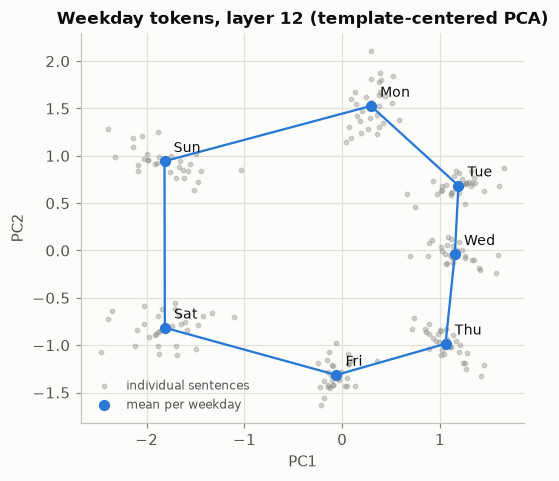

In [9]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
templates = ["Let's meet on {d}", "The store is closed on {d}", "My favorite day is {d}", "She was born on a {d}",
             "The package arrives on {d}", "We usually go hiking on {d}", "The meeting was moved to {d}", "I will call you on {d}",
             "The exam is scheduled for {d}", "He always cooks dinner on {d}", "Every {d}", "Next {d}", "Last {d}", "See you {d}",
             "It rained heavily on {d}", "Our flight leaves on {d}", "The museum is free on {d}", "They play football every {d}",
             "The report is due on {d}", "Is the library open on {d}", "The party is on {d}", "We moved house on {d}",
             "The concert starts on {d}", "Remember to vote on {d}", "The bus does not run on {d}", "Payday is on {d}",
             "The class was cancelled on {d}", "I felt tired all {d}", "Grandma visits every {d}", "The market opens on {d}"]
texts = [t.format(d=d) for t in templates for d in days]
day_idx = np.tile(np.arange(7), len(templates))
tmpl_idx = np.repeat(np.arange(len(templates)), 7)
assert all(tok.convert_ids_to_tokens(tok(t)["input_ids"])[-1].lstrip("Ġ") == days[i] for t, i in zip(texts, day_idx))
D = store.get("days_v1", texts, [PROBE_LAYER], tag="last")[PROBE_LAYER]
Dc = D.copy()
for t in range(len(templates)):
    Dc[tmpl_idx == t] -= D[tmpl_idx == t].mean(0)
pca_d = pl.fit_pca(Dc, k=2)
Zd = pca_d.transform(Dc)
means = np.stack([Zd[day_idx == i].mean(0) for i in range(7)])

# 선형 '요일 번호' 회귀 (template 단위로 나눈 test)
sp_d = pl.group_split([f"t{i}" for i in tmpl_idx], fractions=(0.7, 0.0, 0.3), seed=0)
m_, s_ = D[sp_d.train].mean(0), D[sp_d.train].std(0) + 1e-6
Ztr, Zte = (D[sp_d.train] - m_) / s_, (D[sp_d.test] - m_) / s_
W = np.linalg.solve(Ztr.T @ Ztr + 10 * np.eye(Ztr.shape[1]), Ztr.T @ (day_idx[sp_d.train] - 3.0))
pred = Zte @ W + 3.0
r2 = 1 - np.sum((day_idx[sp_d.test] - pred) ** 2) / np.sum((day_idx[sp_d.test] - day_idx[sp_d.test].mean()) ** 2)
print({"linear 'day index' regression test R²": round(float(r2), 3), "PC1+PC2 variance": round(float(pca_d.explained.sum()), 3)})

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(Zd[:, 0], Zd[:, 1], s=8, color=pl.MUTED, alpha=0.35, label="individual sentences")
ring = np.vstack([means, means[:1]])
ax.plot(ring[:, 0], ring[:, 1], color=pl.C_TRUE, lw=1.5)
ax.scatter(means[:, 0], means[:, 1], s=40, color=pl.C_TRUE, zorder=3, label="mean per weekday")
for (x0, y0), name in zip(means, days):
    ax.annotate(name[:3], (x0, y0), textcoords="offset points", xytext=(6, 6), fontsize=9, color=pl.INK)
ax.set(title=f"Weekday tokens, layer {PROBE_LAYER} (template-centered PCA)", xlabel="PC1", ylabel="PC2")
ax.legend(loc="lower left", fontsize=8)
plt.show()

선형 가정에 대한 반례는 두 방향으로 나온다.

- **성공이 기하를 숨긴다.** 위의 요일처럼, 선형 probe가 잘 맞아도 표현은 원일 수 있다.
- **실패가 정보를 숨긴다.** Othello-GPT의 판 상태는 "흑/백" 기준으로는 비선형 probe가 필요했지만([Li et al. 2023](https://arxiv.org/abs/2210.13382)), "내 돌/상대 돌" 기준으로 label을 바꾸자 **선형**으로 읽혔다([Nanda, Lee & Wattenberg 2023](https://arxiv.org/abs/2309.00941)). 작은 RNN은 순서 정보를 방향이 아니라 **크기**로 담기도 한다("onion" 표현, [Csordás et al. 2024](https://arxiv.org/abs/2408.10920)). 선형 probe의 실패는 "정보가 없다"가 아니라 "이 기준(basis)과 이 형태로는 없다"일 수 있다.

## 주장 장부 — ⑦의 갱신 (심사위원 판정)

| ID | 이전 상태 | ⑦의 근거 | 판정 |
|---|---|---|---|
| C2 | 지지됨 | 무작위 국가 묶음(모델에 없는 개념)도 LR test AUROC 0.99 | **범위 축소:** "probe 용량만으로는 설명되지 않는다"는 유지. 그러나 높은 정확도 + 귀무분포 통과는 **개념의 존재를 보이지 못한다.** 진실 probe를 구별한 것은 일반화와 개입이었다. |
| C4 | 지지됨 (충분성) | prompt 안 분포로 맞춘 LEACE가 문장 끝(8–12)에서 정확도 1.00→0.67(margin ±0.99→±0.20, AUROC 0.70), 답 위치까지(12–20) 지우면 margin +0.18/+0.08(AUROC 0.68). 섞은 label eraser는 1.00. | **강화 + 대상 수정:** 판단에는 prompt 안 특정 위치·층의 선형 진실 정보가 **필요하고(지우면 확신이 거의 사라짐) 충분하다(밀면 뒤집힘).** 지운 뒤에도 남는 순위 정보(AUROC 0.68)는 다른 위치나 비선형 정보에 있다. 그러나 "문장 단독으로 찾은 probe 방향 = 모델의 변수"는 지지되지 않는다(eraser 비전이, 층 의존성, LR 대비). |
| D2 | (신규) | ④ 층 띠 비교 + ⑦ 실험 B/C | **관찰됨:** 판단에 쓰이는 진실 정보는 중간 층에서 문장 끝 위치에서 답 위치로 이동한다. 가장 잘 읽히는 곳과 개입이 통하는 곳은 다르다. |
| M1 | (방법론) | 요일 고리, Othello, onion | **경고:** 선형 probe의 성공·실패는 표현의 기하에 대해 말하지 않는다. |

#### Cell 09 · 결과 저장

- **이번 셀의 질문:** ⑧이 모아 읽을 ⑦의 수치를 기록한다.
- **출력에서 볼 것:** `results/07_use.json` 경로가 출력된다.
- **해석 범위:** 표 세 개를 저장한다.
- **다음 단계의 목적:** ⑧ 반박 3 — 감시 도구로서의 probe, 그리고 최종 판정.

In [10]:
pl.save_results("07_use", {
    "made_up_concepts": made_up.reset_index().to_dict(orient="records"),
    "erasure_decodability": erasure.to_dict(orient="records"),
    "cos_statement_vs_context_dir": pl.cosine(stmt_dir, ctx_dir),
    "amnesic": amnesic.to_dict(orient="records"),
    "weekday_linear_r2": float(r2),
    "claims": [
        {"id": "C2", "status": "범위 축소", "text": "무작위 국가 묶음도 LR 0.99로 읽힌다: 정확도는 개념의 존재를 보이지 못한다."},
        {"id": "C4", "status": "강화 + 대상 수정", "text": "prompt 안 선형 진실 정보는 판단에 필요(지우면 margin ±0.99→≈+0.1)하고 충분(밀면 뒤집힘)하다. 문장 단독 probe 방향 = 모델 변수는 아님 (cos 0.23)."},
        {"id": "D2", "status": "관찰됨", "text": "판단에 쓰이는 정보는 중간 층에서 문장 끝 → 답 위치로 이동한다."},
    ],
})

PosixPath('/workspace/ARENA_3.0/chapter1_transformer_interp/exercises/part31_linear_probes_ko/results/07_use.json')